Loans Data

In [1]:
#import all the necessary items
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

#import dataset
data_path = "loan_data.csv"
df = pd.read_csv(data_path)

#preview data
display(df.head())
df.info()
(df.isna().mean()*100).round(2)



,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


credit.policy        0.0
purpose              0.0
int.rate             0.0
installment          0.0
log.annual.inc       0.0
dti                  0.0
fico                 0.0
days.with.cr.line    0.0
revol.bal            0.0
revol.util           0.0
inq.last.6mths       0.0
delinq.2yrs          0.0
pub.rec              0.0
not.fully.paid       0.0
dtype: float64

In [2]:
df["not.fully.paid"].value_counts()

not.fully.paid
0    8045
1    1533
Name: count, dtype: int64

#0 means that the loan has been paid
#1 means that the loan has not been paid yet 

purpose
debt_consolidation    603
all_other             387
small_business        172
credit_card           146
home_improvement      107
educational            69
major_purchase         49
Name: count, dtype: int64


Text(0.5, 1.0, "Purpose of those who haven't fully paid loan")

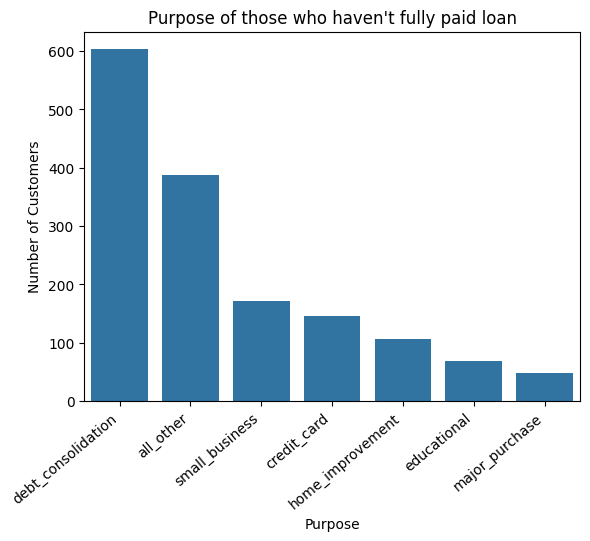

In [3]:
df_notpaid = df[df["not.fully.paid"]==1]

#groupby purpose
purpose_counts = df_notpaid['purpose'].value_counts()
print(purpose_counts)

#graph
plt.figure()
sns.barplot(x=purpose_counts.index, y=purpose_counts.values)
plt.ylabel("Number of Customers")
plt.xlabel("Purpose")
plt.xticks(rotation=40, ha='right')
plt.title("Purpose of those who haven't fully paid loan")



In [ ]:
fico_bins = [0, 579, 669, 739, 799, 850]
fico_labels = ['Poor', 'Fair', 'Good', 'Very Good', 'Exceptional']

df_notpaid['fico_tier'] = pd.cut(df_notpaid['fico'], bins=fico_bins, labels=fico_labels)

/var/folders/2n/xjnxpt2j2dlbg3xlf_mw0_2h0000gn/T/ipykernel_48955/1488472104.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_notpaid['fico_tier'] = pd.cut(df_notpaid['fico'], bins=fico_bins, labels=fico_labels)


Text(0, 0.5, 'Number of customers')

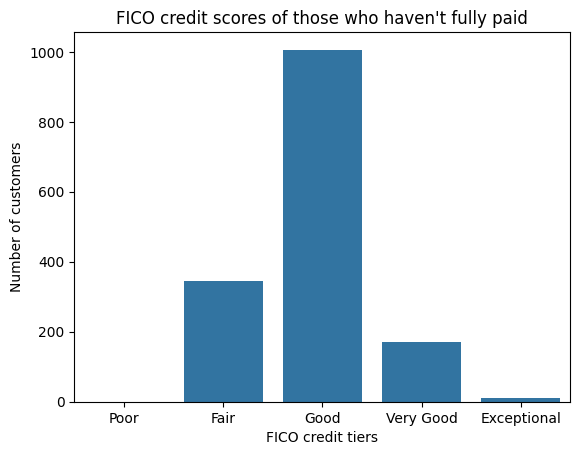

In [13]:
plt.figure()
sns.countplot(data=df_notpaid, x='fico_tier')
plt.title("FICO credit scores of those who haven't fully paid")
plt.xlabel("FICO credit tiers")
plt.ylabel("Number of customers")

In [27]:
df_notpaid['dti'].describe()
df_notpaid.groupby('fico_tier', observed =False)['dti'].mean()
df_notpaid.groupby('fico_tier', observed=False)['int.rate'].mean()
df_notpaid.groupby('fico_tier', observed=False)['revol.util'].mean()

fico_tier
Poor                 NaN
Fair           64.536994
Good           52.809970
Very Good      27.000000
Exceptional     3.340000
Name: revol.util, dtype: float64